In [ ]:
import sys
!{sys.executable} -m pip install momentfm
import sys, os
sys.path.append(os.path.abspath(".."))  # go one level upimport numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import logging
from pathlib import Path
from momentfm import MOMENTPipeline
import scipy
from sklearn.decomposition import PCA
from moment import load_mean_activations
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from clustering.plotting import plot_knn_3d, plot_knn
#from hough_scripts.separability import embeddings_pca_corr, lda_pca_embeddings, embeddings_umap


/home/ekaczmarczyk/anaconda3/envs/reps-tsfm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ekaczmarczyk/anaconda3/envs/reps-tsfm/lib/python3.10/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/home/ekaczmarczyk/anaconda3/envs/reps-tsfm/lib/python3.10/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [2]:
def compute_knn(activations, n_components):
    
    '''activation - np.array of shape (n_transfer, n_samples, 1024)
       n_components - int PCA dimension
       computes knn on embeddings after PCA reduction'''
    
    n_transform = activations.shape[0]
    n_samples = activations.shape[1]
    
    combined = activations.reshape(-1, activations.shape[-1])
    reducer = PCA(n_components=n_components)

    combined_reduced = reducer.fit_transform(combined)
    reduced_list = []
    
    for i in range(n_transform):
        reduced_list.append(combined_reduced[n_samples*i:n_samples*(i+1)])
    print(reduced_list[0].shape)
    
    X = np.vstack(reduced_list)
    l = []
    for i in range(n_transform):
        l += [i] * n_samples
    y = np.array(l)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)


    print("n_components:"+ str(n_components))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    return X_test, y_test, y_pred


In [8]:
# Load activations, shape will be: (n_transform, num_samples, dimension)
path = "/mnt/c/Users/emika/OneDrive/Pulpit/Studia 4. rok/RISS/representations-in-tsfms-main/representations-in-tsfms-main/clustering/activations/"
#path = "/zfsauton2/home/ekaczmar/representations-in-tsfms-main/representations-in-tsfms-main/clustering/activations/"
activations_exps = np.load(os.path.join(path,'activations_exps.npy'))
activations_sines = np.load(os.path.join(path,'activations_sines.npy'))
activations_trends = np.load(os.path.join(path,'activations_trends.npy'))

n_transform = activations_exps.shape[0]



In [9]:
#Compute knn classification

n_components = 5 #,5,10,50,100]
X_test_t, y_test_t, y_pred_t = compute_knn(activations_trends, n_components)
X_test_e, y_test_e, y_pred_e = compute_knn(activations_exps, n_components)
X_test_s, y_test_s, y_pred_s = compute_knn(activations_sines, n_components)


(100, 5)
n_components:5
Accuracy: 0.945

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       0.95      1.00      0.98        20
           4       0.95      1.00      0.98        20
           5       0.89      0.85      0.87        20
           6       0.95      0.95      0.95        20
           7       0.79      0.95      0.86        20
           8       1.00      0.85      0.92        20
           9       0.95      0.90      0.92        20

    accuracy                           0.94       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.94      0.95       200


Confusion Matrix:
 [[20  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 19  1  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  

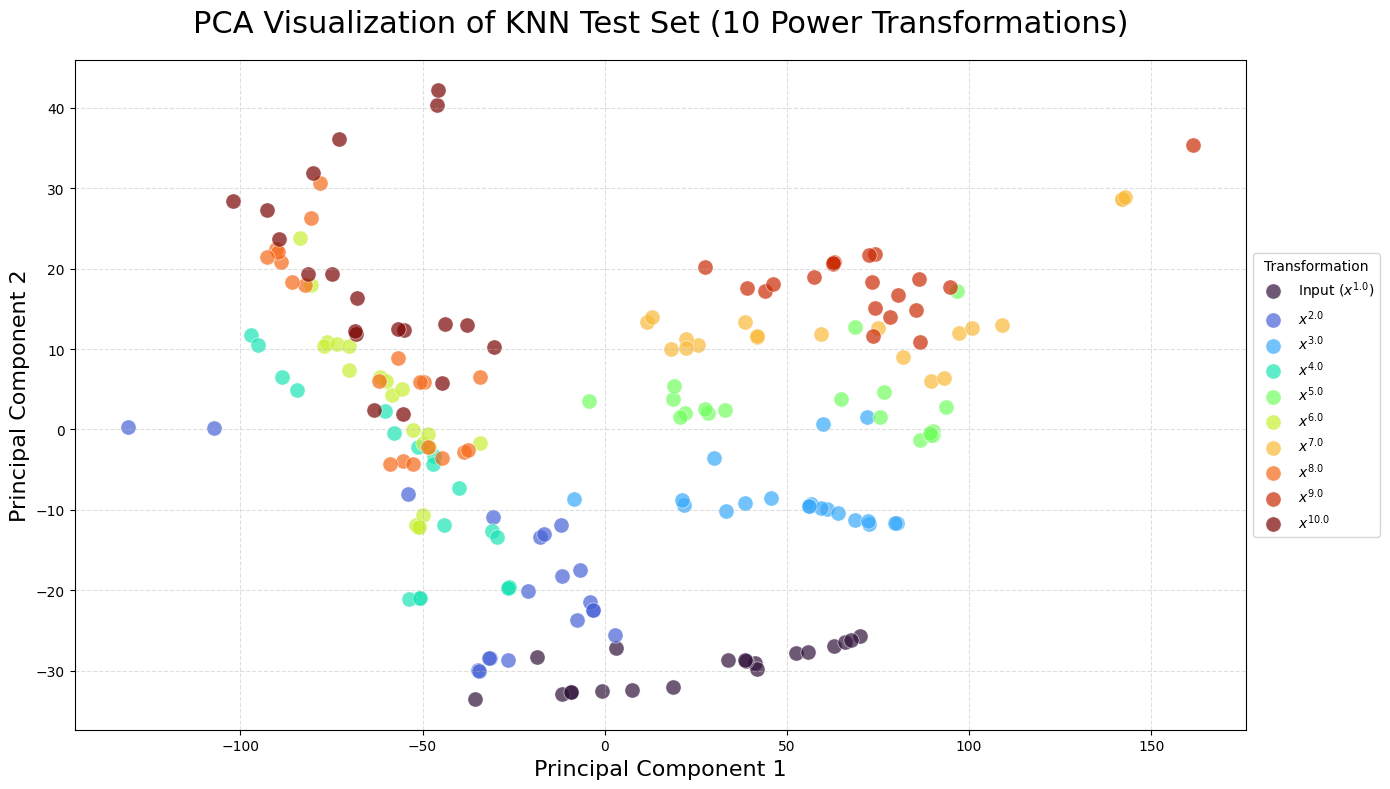

In [14]:
plot_knn(X_test_s, y_test_s, n_transform=n_transform)

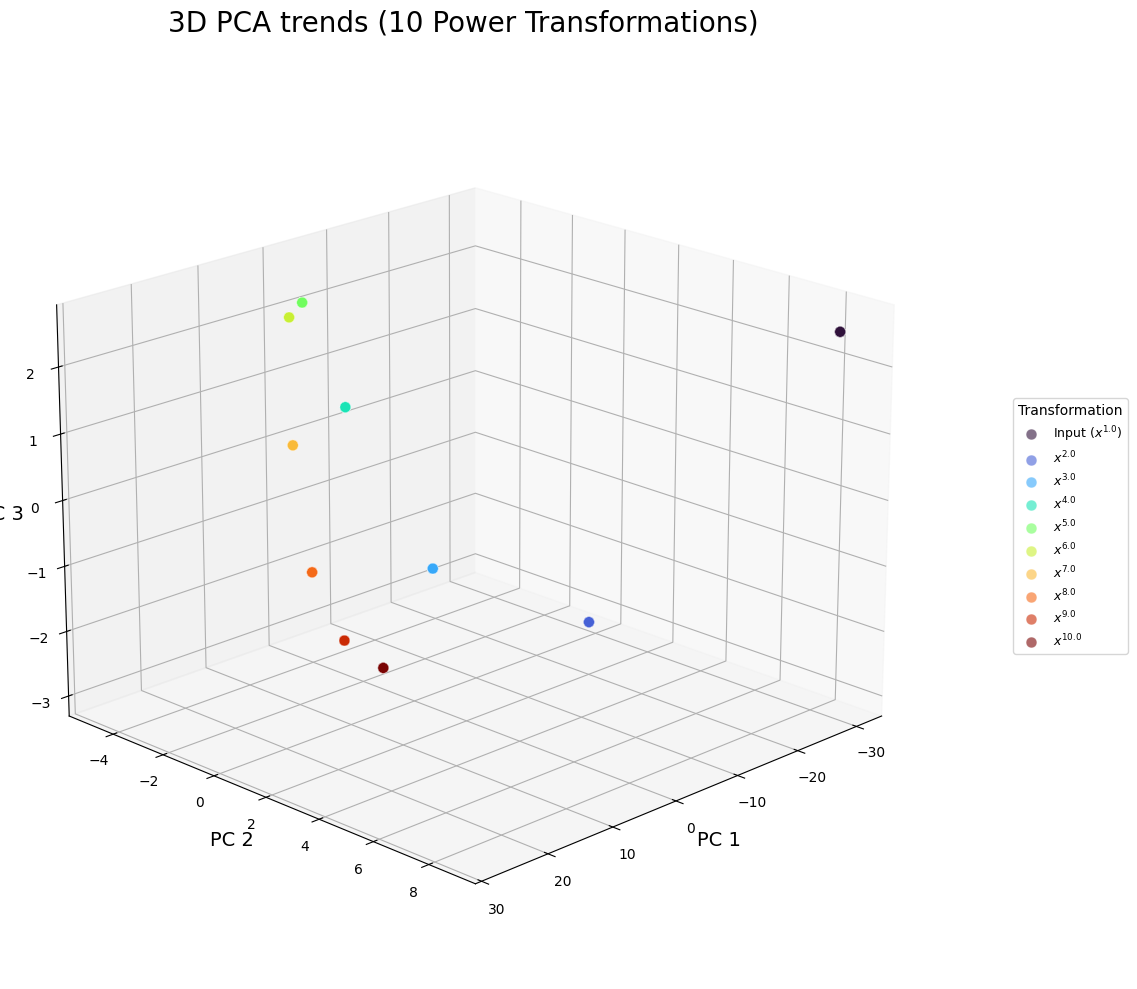

In [13]:
plot_knn_3d(X_test_e, y_test_e, n_transform=n_transform)